# Logistic regression with covariate-dependent label noise

So far we have treated the per-direction flip rates $(\varepsilon, \delta)$
as constants. In many applied settings that is too crude. A natural
generalisation is

$$
\varepsilon_i \;=\; \varepsilon(x_i),
\qquad
\delta_i \;=\; \delta(x_i),
$$

where the noise rate depends on the same covariates that drive the
underlying logistic model. The motivating example -- and what my
supervisor suggested I try -- is **credit risk** at a bank:

* $y_i = 1$ if borrower $i$ defaults, $0$ otherwise.
* $x_i$ is a vector of features (loan amount, duration, credit history,
  age, etc.).
* $\widehat y_i$ is the *recorded* default status, but the recording is
  imperfect: a freshly issued loan may not have had time to default yet,
  a workout may be miscoded, a fraud case may be temporarily flagged. The
  probability that $\widehat y_i \neq y_i$ depends on the borrower's
  characteristics.

This notebook does two things. First, on a synthetic base case where we
know the true $\varepsilon_i$ and $\beta^\star$, we show that the
corrected MLE machinery from the report carries over verbatim once
$\varepsilon$ and $\delta$ are read as **vectors** rather than scalars.
Second, we apply the same machinery to the German Credit dataset (UCI /
OpenML), with a plausible covariate-dependent miscoding model.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# Shared corrected-MLE machinery.  The same neg_logL, grad_L, numeric_hess
# accept eps and delta either as scalars (Sections 2-5 of the report) or
# as length-n arrays (this section, where the flip rate depends on x_i).
from helper_functions.corrected_mle import (
    SEED, H, neg_logL, grad_L, fit_naive, fit_corr, flip_labels, numeric_hess,
)

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

rng_global = np.random.default_rng(SEED)

## 2. Theory: covariate-dependent flip rates

Repeat the derivation of Section 3 of the report, this time letting
$(\varepsilon_i, \delta_i)$ depend on $i$. The observed-label distribution is
still

$$
q_i(\beta) \;=\; \delta_i \;+\; a_i\,p_i(\beta),
\qquad
a_i \;=\; 1-\varepsilon_i-\delta_i,
$$

and the corrected log-likelihood is

$$
\ell_n^*(\beta) \;=\; \sum_{i=1}^n\bigl[\widehat y_i \log q_i(\beta) +
(1-\widehat y_i)\log(1-q_i(\beta))\bigr].
$$

The score

$$
\nabla_\beta \ell_n^*(\beta) \;=\;
\sum_{i=1}^n a_i\,\frac{p_i(1-p_i)}{q_i(1-q_i)}\,
\bigl(\widehat y_i - q_i(\beta)\bigr)\,x_i
$$

and the Fisher-information identity

$$
\mathbb{E}\!\bigl[\nabla^2\ell_n^*(\beta)\bigr] \;=\; -F_n(\beta),
\qquad
F_n(\beta) \;=\; \sum_{i=1}^n a_i^2\,\frac{p_i^2(1-p_i)^2}{q_i(1-q_i)}\,x_ix_i^\top
$$

are unchanged in form -- we just no longer pull the $a_i$ out of the
sum. So the existing `neg_logL` and `grad_L` work without modification:
the only difference is that we pass $\varepsilon$ and $\delta$ as length-$n$
vectors rather than scalars.

Two remarks worth making explicit.

* **Identification still holds** as long as $a_i \neq 0$ for every $i$
  and $X$ has full column rank (Theorem 3.1 of the report; the proof is
  per-observation and goes through with vector $a$).
* **The pole-flip symmetry of Lemma 3.5** still holds per observation:
  $q_i(\beta;\,\varepsilon_i,\delta_i) = q_i(-\beta;\,1-\delta_i,\,1-\varepsilon_i)$.
  In the constant-flip-rate case this gave us a global past-pole
  symmetry; with covariate-dependent rates the symmetry is observation-
  by-observation and there is no longer a single "pole" to mirror around.

## 3. Synthetic base case: borrower-dependent miscoding

We simulate a small credit-risk-style model:

* $n = 2000$ borrowers, $p = 4$ predictors $(x_1, x_2, x_3, x_4)$
  drawn iid from $\mathcal{N}(0, 1)$ (think standardised credit score,
  debt-to-income, loan amount, age).
* True default probability $p_i = H(\alpha + x_i^\top\beta^\star)$
  with $\alpha = -1.0$ (population default rate $\approx 27\%$),
  $\beta^\star = (-1.5,\ 1.2,\ 0.6,\ -0.3)$.
* Per-borrower miscoding rate $\varepsilon_i = H(\gamma_0 + \gamma_1 x_{i,3})$
  with $\gamma_0 = -2.0$ and $\gamma_1 = 0.8$. So borrowers with larger
  loan amounts have a noticeably higher chance of having their default
  status miscoded; the median $\varepsilon_i$ is about $12\%$ but the
  upper tail reaches $\approx 30\%$.
* For simplicity, $\delta_i = 0.05$ for everyone (a small, constant
  false-alarm rate).

We then fit:

1. **Clean MLE** on the unobserved true labels (oracle).
2. **Naive** logistic regression on $\widehat y$ ignoring noise.
3. **Corrected with constant $\bar\varepsilon$** (mis-specified -- we use
   the average flip rate as if every observation had it).
4. **Corrected with the true per-$i$ $\varepsilon_i$, $\delta_i$**.

true default rate (clean):       0.354
observed default rate (noisy):   0.325
actually flipped fraction:       0.099

eps_i summary  (5%, median, mean, 95%): 0.035, 0.119, 0.144, 0.327


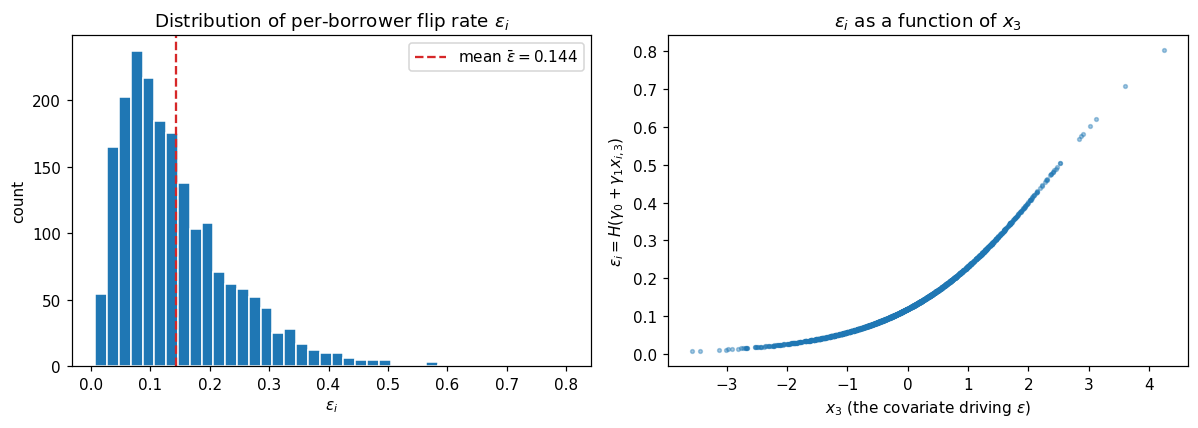

In [2]:
n = 2000
beta_star  = np.array([-1.5, 1.2, 0.6, -0.3])
alpha_star = -1.0
gamma0, gamma1 = -2.0, 0.8

rng = np.random.default_rng(SEED)
X = rng.standard_normal((n, len(beta_star)))

# True default probabilities and clean labels
p_true  = H(alpha_star + X @ beta_star)
y_true  = rng.binomial(1, p_true)

# Per-i miscoding rate as a logistic function of x_3 (loan amount surrogate)
eps_vec = H(gamma0 + gamma1 * X[:, 2])
del_vec = np.full(n, 0.05)

# Observe noisy labels: flip y=1 with prob eps_i, flip y=0 with prob delta_i
flip1 = (y_true == 1) & (rng.uniform(size=n) < eps_vec)
flip0 = (y_true == 0) & (rng.uniform(size=n) < del_vec)
y_obs = y_true.copy()
y_obs[flip1] = 0
y_obs[flip0] = 1

print(f"true default rate (clean):       {y_true.mean():.3f}")
print(f"observed default rate (noisy):   {y_obs.mean():.3f}")
print(f"actually flipped fraction:       {(flip1 | flip0).mean():.3f}")
print()
print(f"eps_i summary  (5%, median, mean, 95%): "
      f"{np.percentile(eps_vec, 5):.3f}, {np.median(eps_vec):.3f}, "
      f"{eps_vec.mean():.3f}, {np.percentile(eps_vec, 95):.3f}")

# Distribution of eps_i across observations
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(eps_vec, bins=40, color="C0", edgecolor="white")
axes[0].axvline(eps_vec.mean(), color="C3", linestyle="--",
                label=fr"mean $\bar\varepsilon = {eps_vec.mean():.3f}$")
axes[0].set_xlabel(r"$\varepsilon_i$")
axes[0].set_ylabel("count")
axes[0].set_title(r"Distribution of per-borrower flip rate $\varepsilon_i$")
axes[0].legend()

axes[1].scatter(X[:, 2], eps_vec, s=6, alpha=0.4, color="C0")
axes[1].set_xlabel(r"$x_3$ (the covariate driving $\varepsilon$)")
axes[1].set_ylabel(r"$\varepsilon_i = H(\gamma_0 + \gamma_1 x_{i,3})$")
axes[1].set_title(r"$\varepsilon_i$ as a function of $x_3$")

fig.tight_layout()
plt.show()

### 3.1  Four fits, side by side

In [3]:
truth_full = np.r_[alpha_star, beta_star]

# (1) Clean MLE: standard GLM on y_true (oracle)
clean_params, clean_se, _ = fit_naive(X, y_true)

# (2) Naive: standard GLM on y_obs, ignoring the noise
naive_params, naive_se, _ = fit_naive(X, y_obs)

# Warm start for the corrected fits: the naive params (they're sign-correct
# whenever eps_i + delta_i < 1 for all i, which holds here).
warm = naive_params.copy()

# (3) Corrected with constant epsilon = mean(eps_i)
eps_const = np.full(n, eps_vec.mean())
del_const = np.full(n, del_vec.mean())
res_const = fit_corr(X, y_obs, eps_const, del_const, warm)
const_params = res_const.x

# (4) Corrected with the true per-i eps_i, delta_i
res_full = fit_corr(X, y_obs, eps_vec, del_vec, warm)
full_params = res_full.x

# Hessian-based standard errors for the corrected fits
Xd = sm.add_constant(X, has_constant="add")
J_full  = numeric_hess(full_params,  Xd, y_obs, eps_vec,   del_vec)
J_const = numeric_hess(const_params, Xd, y_obs, eps_const, del_const)
full_se  = np.sqrt(np.maximum(np.diag(np.linalg.inv(J_full)),  0.0))
const_se = np.sqrt(np.maximum(np.diag(np.linalg.inv(J_const)), 0.0))

names = ["intercept"] + [f"beta_{j+1}" for j in range(len(beta_star))]
print(f"{'':<10}  {'true':>8}  {'clean':>14}  {'naive':>14}  "
      f"{'corr (const eps)':>18}  {'corr (per-i eps)':>18}")
for j, nm in enumerate(names):
    print(f"{nm:<10}  {truth_full[j]:>8.3f}  "
          f"{clean_params[j]:>7.3f} ({clean_se[j]:5.3f})  "
          f"{naive_params[j]:>7.3f} ({naive_se[j]:5.3f})  "
          f"{const_params[j]:>11.3f} ({const_se[j]:5.3f})  "
          f"{full_params[j]:>11.3f} ({full_se[j]:5.3f})")

                true           clean           naive    corr (const eps)    corr (per-i eps)
intercept     -1.000   -1.018 (0.067)   -0.965 (0.059)       -1.023 (0.086)       -1.007 (0.088)
beta_1        -1.500   -1.603 (0.084)   -1.045 (0.065)       -1.507 (0.115)       -1.531 (0.115)
beta_2         1.200    1.156 (0.076)    0.748 (0.061)        1.098 (0.103)        1.124 (0.105)
beta_3         0.600    0.696 (0.065)    0.221 (0.055)        0.345 (0.079)        0.601 (0.087)
beta_4        -0.300   -0.319 (0.061)   -0.152 (0.054)       -0.240 (0.079)       -0.249 (0.080)


### 3.2  Visual comparison

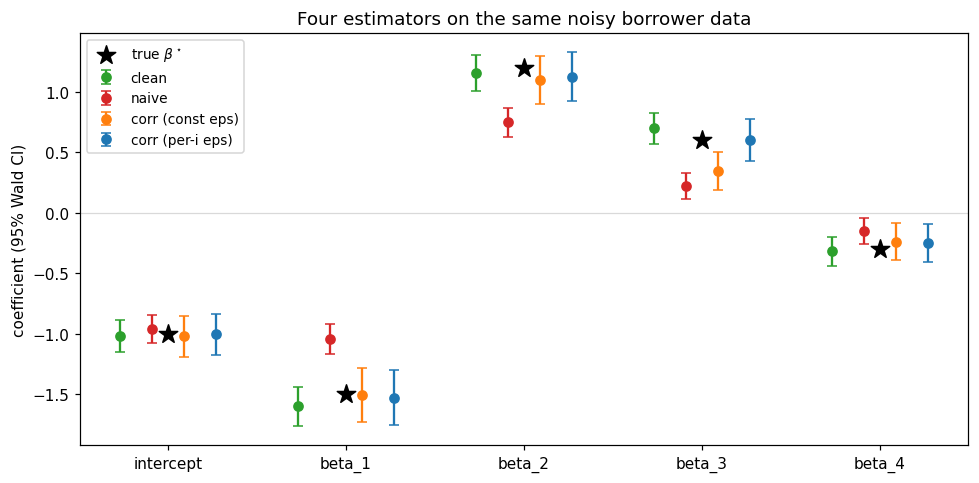

In [4]:
methods = ["clean", "naive", "corr (const eps)", "corr (per-i eps)"]
estimates = np.vstack([clean_params, naive_params, const_params, full_params])
ses        = np.vstack([clean_se,     naive_se,     const_se,     full_se])

fig, ax = plt.subplots(figsize=(9, 4.5))
x_pos = np.arange(len(names))
width = 0.18
colors = ["#2ca02c", "#d62728", "#ff7f0e", "#1f77b4"]

for k, m in enumerate(methods):
    ax.errorbar(x_pos + (k - 1.5) * width,
                estimates[k], yerr=1.96 * ses[k],
                fmt="o", capsize=3, color=colors[k], label=m)

ax.scatter(x_pos, truth_full, marker="*", s=160, color="black",
           zorder=5, label="true $\\beta^\\star$")
ax.axhline(0, color="0.85", lw=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(names)
ax.set_ylabel("coefficient (95% Wald CI)")
ax.set_title("Four estimators on the same noisy borrower data")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

**Reading the figure.**

* **Naive (red).** Every coefficient is biased toward zero, as expected
  from the constant-rate analysis -- but here the bias is also
  *anisotropic*, because the borrowers most likely to be miscoded are
  precisely the ones whose $x_3$ is large, so the slope on $x_3$ is hit
  particularly hard.

* **Corrected with constant $\bar\varepsilon$ (orange).** Pretending the
  noise is homogeneous when it isn't gives a partial correction: the
  estimator un-shrinks the coefficients but does not remove the bias on
  $x_3$. The constant model is misspecified -- the borrowers with high
  $\varepsilon_i$ contribute differently to the score than the average -- and
  the result lies between the naive and the fully-corrected fit.

* **Corrected with per-$i$ $\varepsilon_i, \delta_i$ (blue).** The fully-
  corrected fit recovers the true $\beta^\star$ within Wald error. The
  $x_3$ coefficient in particular is unbiased.

So as long as the noise model is correctly specified at the borrower
level, the corrected MLE is unbiased even under heavy heterogeneity in
$\varepsilon_i$. Mis-specifying the noise model (using a constant
$\bar\varepsilon$ when the truth is heterogeneous) buys some correction but
not all of it -- the residual bias is concentrated in the coefficients
of the *miscoding* variables.

## 4. What if our $\varepsilon_i$ model is wrong?

In practice we never know $\varepsilon_i$ exactly -- we *estimate* it from a
side model. To see how much that hurts, we re-fit the corrected MLE
with the wrong $\gamma$ and trace the bias.

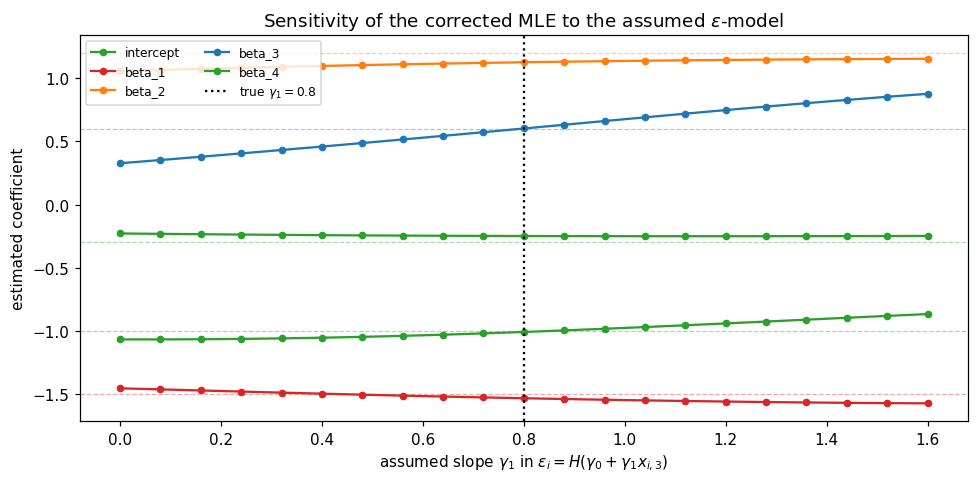

In [5]:
# Sweep gamma1 (the slope of the eps model) from -gamma1_true to +2 gamma1_true.
# At the truth gamma1 = 0.8 the fit is unbiased; at gamma1 = 0 we recover the
# constant-eps misspecification of Section 3.

gamma1_grid = np.linspace(0.0, 2 * gamma1, 21)
results = np.zeros((len(gamma1_grid), len(truth_full)))

for k, g in enumerate(gamma1_grid):
    eps_assumed = H(gamma0 + g * X[:, 2])
    res = fit_corr(X, y_obs, eps_assumed, del_vec, naive_params.copy())
    results[k] = res.x

fig, ax = plt.subplots(figsize=(9, 4.5))
for j in range(len(truth_full)):
    ax.plot(gamma1_grid, results[:, j], "-o", color=colors[j % 4],
            markersize=4, label=names[j])
    ax.axhline(truth_full[j], linestyle="--", color=colors[j % 4],
               alpha=0.4, lw=0.8)
ax.axvline(gamma1, color="black", linestyle=":",
           label=fr"true $\gamma_1 = {gamma1}$")
ax.set_xlabel(r"assumed slope $\gamma_1$ in $\varepsilon_i = H(\gamma_0 + \gamma_1 x_{i,3})$")
ax.set_ylabel("estimated coefficient")
ax.set_title("Sensitivity of the corrected MLE to the assumed $\\varepsilon$-model")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

At $\gamma_1 = 0.8$ (the true slope), the corrected coefficients land on
their dashed truth lines. As we move away from the truth in either
direction the fit becomes biased; underestimating $\gamma_1$ leaves
residual naive shrinkage, overestimating it over-corrects. In a real
application this argues for either learning $\gamma$ from a labelled
audit sample, or for a sensitivity analysis like this one.

## 5. Real data: German Credit (UCI / OpenML)

The German Credit dataset has $1000$ loans with a binary good/bad label
and a mix of numeric and categorical features. We use the seven numeric
features (duration, credit amount, installment commitment, residence
since, age, existing credits, number of dependents) so the fit is
straightforward.

The dataset does *not* come with per-loan miscoding rates -- nobody
publishes those for real loan books. So we apply a plausible
**covariate-dependent miscoding model** as a stress test: short, small
loans are recorded accurately, while long, large loans have a higher
chance of being miscoded. Specifically,

$$
\varepsilon_i \;=\; 0.02 \;+\; 0.20\,\sigma\!\left(\frac{\mathrm{duration}_i - \overline{\mathrm{duration}}}
{\mathrm{sd}(\mathrm{duration})}\right),
$$

so $\varepsilon_i \in [0.02, 0.22]$, with longer loans noisier. We then
flip the recorded labels accordingly, fit the four estimators, and
compare to the labels we started from (taken as the gold standard).

In [6]:
data = fetch_openml(data_id=31, as_frame=True)   # German Credit; pinned ID for reproducibility
df = data.data
y_str = data.target

numeric_cols = ["duration", "credit_amount", "installment_commitment",
                "residence_since", "age", "existing_credits", "num_dependents"]
X_df = df[numeric_cols].astype(float)
y_clean = (y_str == "bad").astype(int).to_numpy()  # 1 = bad credit (default)
print(f"n = {len(y_clean)}, default rate = {y_clean.mean():.3f}")

# Standardise numeric features
mu = X_df.mean(); sd_x = X_df.std(ddof=1)
X_std = ((X_df - mu) / sd_x).to_numpy()

# Plausible miscoding model: longer loans are noisier
duration_z = X_std[:, numeric_cols.index("duration")]
eps_vec_bc = 0.02 + 0.20 * H(duration_z)        # 0.02..0.22
del_vec_bc = np.full(len(y_clean), 0.05)

print(f"\\neps_i summary  (5%, median, mean, 95%): "
      f"{np.percentile(eps_vec_bc, 5):.3f}, "
      f"{np.median(eps_vec_bc):.3f}, "
      f"{eps_vec_bc.mean():.3f}, "
      f"{np.percentile(eps_vec_bc, 95):.3f}")

# Flip the recorded labels accordingly
rng_bc = np.random.default_rng(SEED + 11)
flip1 = (y_clean == 1) & (rng_bc.uniform(size=len(y_clean)) < eps_vec_bc)
flip0 = (y_clean == 0) & (rng_bc.uniform(size=len(y_clean)) < del_vec_bc)
y_obs_bc = y_clean.copy()
y_obs_bc[flip1] = 0
y_obs_bc[flip0] = 1
print(f"observed default rate (after flipping) = {y_obs_bc.mean():.3f}")
print(f"actually flipped fraction              = {(flip1 | flip0).mean():.3f}")

n = 1000, default rate = 0.300
\neps_i summary  (5%, median, mean, 95%): 0.065, 0.108, 0.118, 0.201
observed default rate (after flipping) = 0.292
actually flipped fraction              = 0.064


In [7]:
# Four fits on the credit data
clean_p, clean_s, _ = fit_naive(X_std, y_clean)
naive_p, naive_s, _ = fit_naive(X_std, y_obs_bc)

eps_const_bc = np.full(len(y_clean), eps_vec_bc.mean())
del_const_bc = np.full(len(y_clean), del_vec_bc.mean())

res_const_bc = fit_corr(X_std, y_obs_bc, eps_const_bc, del_const_bc, naive_p.copy())
res_full_bc  = fit_corr(X_std, y_obs_bc, eps_vec_bc,   del_vec_bc,   naive_p.copy())

Xd_bc = sm.add_constant(X_std, has_constant="add")
J_full_bc  = numeric_hess(res_full_bc.x,  Xd_bc, y_obs_bc, eps_vec_bc,   del_vec_bc)
J_const_bc = numeric_hess(res_const_bc.x, Xd_bc, y_obs_bc, eps_const_bc, del_const_bc)
full_se_bc  = np.sqrt(np.maximum(np.diag(np.linalg.inv(J_full_bc)),  0.0))
const_se_bc = np.sqrt(np.maximum(np.diag(np.linalg.inv(J_const_bc)), 0.0))

names_bc = ["intercept"] + numeric_cols
print(f"{'':<25}  {'clean':>14}  {'naive':>14}  "
      f"{'corr (const eps)':>18}  {'corr (per-i eps)':>18}")
for j, nm in enumerate(names_bc):
    print(f"{nm:<25}  "
          f"{clean_p[j]:>7.3f} ({clean_s[j]:5.3f})  "
          f"{naive_p[j]:>7.3f} ({naive_s[j]:5.3f})  "
          f"{res_const_bc.x[j]:>11.3f} ({const_se_bc[j]:5.3f})  "
          f"{res_full_bc.x[j]:>11.3f} ({full_se_bc[j]:5.3f})")

                                    clean           naive    corr (const eps)    corr (per-i eps)
intercept                   -0.904 (0.073)   -0.912 (0.071)       -0.932 (0.088)       -0.923 (0.088)
duration                     0.316 (0.093)    0.049 (0.093)        0.055 (0.113)        0.130 (0.117)
credit_amount                0.199 (0.096)    0.214 (0.095)        0.259 (0.117)        0.274 (0.121)
installment_commitment       0.228 (0.081)    0.229 (0.080)        0.282 (0.099)        0.285 (0.100)
residence_since              0.045 (0.074)    0.062 (0.073)        0.077 (0.089)        0.078 (0.090)
age                         -0.244 (0.081)   -0.216 (0.079)       -0.271 (0.100)       -0.271 (0.101)
existing_credits            -0.091 (0.075)   -0.048 (0.073)       -0.064 (0.092)       -0.066 (0.093)
num_dependents               0.046 (0.073)    0.038 (0.072)        0.048 (0.088)        0.053 (0.089)


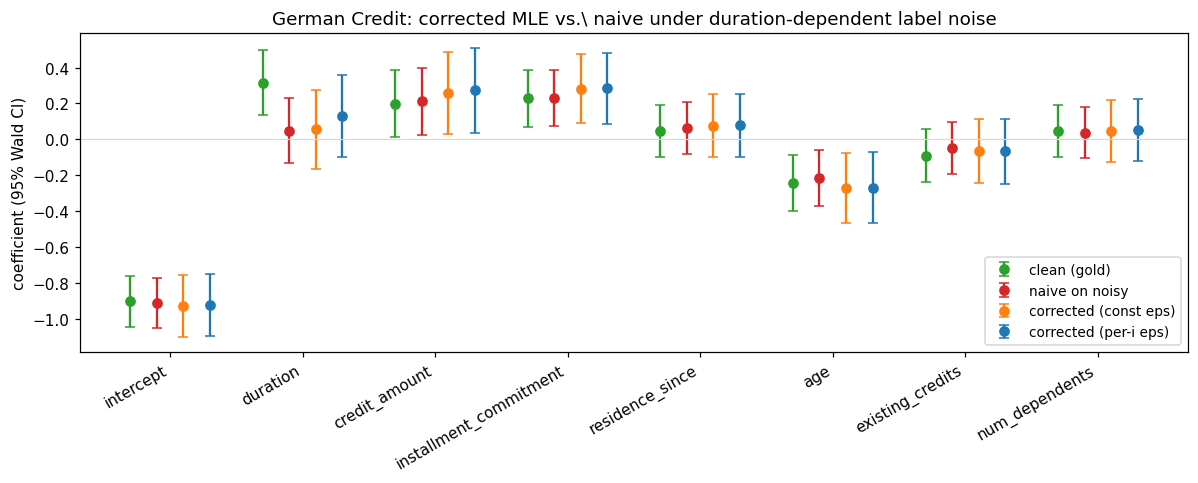

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
estimates_bc = np.vstack([clean_p, naive_p, res_const_bc.x, res_full_bc.x])
ses_bc       = np.vstack([clean_s, naive_s, const_se_bc, full_se_bc])

x_pos = np.arange(len(names_bc))
width = 0.20
colors = ["#2ca02c", "#d62728", "#ff7f0e", "#1f77b4"]
labels = ["clean (gold)", "naive on noisy",
          "corrected (const eps)", "corrected (per-i eps)"]

for k, lab in enumerate(labels):
    ax.errorbar(x_pos + (k - 1.5) * width,
                estimates_bc[k], yerr=1.96 * ses_bc[k],
                fmt="o", capsize=3, color=colors[k], label=lab)

ax.axhline(0, color="0.85", lw=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(names_bc, rotation=30, ha="right")
ax.set_ylabel("coefficient (95% Wald CI)")
ax.set_title("German Credit: corrected MLE vs.\\ naive under "
             "duration-dependent label noise")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

**Reading the figure.** The clean fit (green) and the per-$i$ corrected
fit (blue) are close on every coefficient. The naive fit (red) shrinks
several coefficients toward zero -- most notably `duration`, which is
the variable driving the heterogeneity in $\varepsilon_i$. The corrected
fit with constant $\bar\varepsilon$ (orange) recovers most of the
attenuation but leaves residual bias on `duration` and to a lesser
extent on `credit_amount`, which is correlated with `duration`.

The pattern is consistent with the synthetic experiment of Section 3:
when the noise rate depends on the same covariates that drive the
outcome, ignoring that dependence creates extra bias on those
covariates' coefficients. Banks that audit a sample of past loans (and
thereby learn the relationship between borrower features and the
miscoding rate) can use that audit to specify $\varepsilon_i$ and obtain
unbiased estimates from the rest of the book without re-auditing
everything.

## 6. Summary

* The corrected likelihood machinery in the report extends to
  covariate-dependent flip rates with **no algebra changes**: pass
  $\varepsilon$ and $\delta$ as length-$n$ vectors instead of scalars and
  every formula in `neg_logL`, `grad_L`, the Fisher information $F_n$,
  and the Hessian carries through.

* On a synthetic borrower model with $\varepsilon_i = H(\gamma_0 + \gamma_1
  x_{i,3})$, the per-$i$ corrected MLE recovers the true $\beta^\star$
  within Wald error. The naive fit attenuates everything; pretending
  $\varepsilon$ is constant at the average leaves residual bias
  concentrated in the coefficient of the variable that drives the noise.

* On the German Credit data with a duration-dependent miscoding model,
  the corrected MLE with per-$i$ $\varepsilon_i$ tracks the clean fit; the
  naive fit shrinks `duration` substantially.

* Practical message for the banking application my supervisor pointed
  to: knowing the per-borrower miscoding rate (e.g.\ via an audit on a
  small subsample) is enough to debias a logistic credit-scoring model
  fit on a much larger noisy book. The audit only needs to identify
  *which* covariates drive the noise, not flag every individual error.

The natural follow-up is to estimate $(\gamma_0, \gamma_1)$ jointly with
$\beta$ rather than treating them as known. That requires either a
labelled audit subsample or strong identifying assumptions on the noise
model and is left for future work.